In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.cluster import KMeans

In [2]:
fdrec=pd.read_csv("fdrec.csv")
fdrec_modificado=fdrec[["theta","phi","dec","totalEnergy","dtotalEnergy","calEnergy","dcalEnergy","xmax"
                    ,"heightXmax","dEdXmax","dxmax"]]

In [3]:
fdrec_modificado

,theta,phi,dec,totalEnergy,dtotalEnergy,calEnergy,dcalEnergy,xmax,heightXmax,dEdXmax,dxmax
0,48.21,157.74,-8.98,2.228,0.162,1.912,0.137,713.62,6347.15,3.30,17.74
1,46.34,255.79,-76.14,0.758,0.052,0.634,0.041,761.40,5583.04,1.14,15.77
2,27.71,349.57,-35.55,14.812,1.246,12.921,1.087,735.54,3901.78,21.93,13.74
3,45.88,118.58,6.33,1.813,0.121,1.550,0.101,721.54,5933.16,2.65,13.22
4,23.81,34.96,-19.71,0.949,0.069,0.801,0.057,623.71,4983.36,1.37,16.70
...,...,...,...,...,...,...,...,...,...,...,...
3382,28.24,143.88,-16.19,0.383,0.028,0.315,0.022,647.50,4928.46,0.59,12.32
3383,19.42,40.73,-21.42,0.142,0.011,0.114,0.008,540.78,5784.98,0.21,27.21
3384,22.75,50.37,-16.67,0.228,0.017,0.185,0.013,667.02,4347.90,0.35,12.57
3385,19.87,261.26,-54.67,0.365,0.028,0.301,0.022,648.45,4444.42,0.54,15.34


In [4]:
# Escalamiento de los datos
escalador = MinMaxScaler().fit(fdrec_modificado)
datos_escalados = pd.DataFrame(escalador.transform(fdrec_modificado),
                                columns=fdrec_modificado.columns)

# Entrenamiento del modelo KMeans
modelo_kmeans = KMeans(n_clusters=2, random_state=0).fit(datos_escalados)

# Etiquetas asignadas a cada instancia
etiquetas = modelo_kmeans.labels_
datos_escalados["etiquetas"]=etiquetas
datos_escalados

,theta,phi,dec,totalEnergy,dtotalEnergy,calEnergy,dcalEnergy,xmax,heightXmax,dEdXmax,dxmax,etiquetas
0,0.627368,0.437731,0.646855,0.035597,0.030233,0.034928,0.029084,0.367224,0.467866,0.037951,0.257225,0
1,0.601702,0.710357,0.105242,0.011326,0.009051,0.010877,0.008091,0.453280,0.386623,0.012334,0.219268,1
2,0.346006,0.971111,0.432581,0.243367,0.238976,0.242105,0.236825,0.406704,0.207865,0.258895,0.180154,1
3,0.595388,0.328847,0.770323,0.028745,0.022338,0.028115,0.021211,0.381488,0.423849,0.030242,0.170135,0
4,0.292479,0.096344,0.560323,0.014480,0.012324,0.014020,0.011590,0.205288,0.322863,0.015062,0.237187,0
...,...,...,...,...,...,...,...,...,...,...,...,...
3382,0.353280,0.399194,0.588710,0.005135,0.004429,0.004874,0.003936,0.248136,0.317025,0.005811,0.152794,0
3383,0.232226,0.112387,0.546532,0.001156,0.001155,0.001091,0.000875,0.055924,0.408094,0.001305,0.439692,0
3384,0.277930,0.139191,0.584839,0.002576,0.002311,0.002428,0.001968,0.283293,0.255298,0.002965,0.157611,0
3385,0.238402,0.725567,0.278387,0.004838,0.004429,0.004611,0.003936,0.249847,0.265560,0.005218,0.210983,1


In [5]:
#len(datos_escalados.loc[datos_escalados["etiquetas"]==0])
print(modelo_kmeans.cluster_centers_,modelo_kmeans.inertia_)

[[0.49460336 0.24635944 0.65694392 0.03863942 0.03438095 0.03799925
  0.03323552 0.39841486 0.33842314 0.04083053 0.24628933]
 [0.4987445  0.75733247 0.29677041 0.0353688  0.03118271 0.03473883
  0.03005076 0.40129741 0.34107599 0.03764761 0.24680996]] 411.8990882006771


In [6]:
# Volver a la escala original, quitando la columna 'etiquetas' para evitar errores
datos_sin_etiquetas = datos_escalados.drop(columns=["etiquetas"])

# Usamos inverse_transform() para desescalar
datos_originales = pd.DataFrame(escalador.inverse_transform(datos_sin_etiquetas),
                                columns=fdrec_modificado.columns)

# Si quieres añadir nuevamente las etiquetas:
datos_originales["etiquetas"] = datos_escalados["etiquetas"].values

# Resultado
datos_originales


,theta,phi,dec,totalEnergy,dtotalEnergy,calEnergy,dcalEnergy,xmax,heightXmax,dEdXmax,dxmax,etiquetas
0,48.21,157.74,-8.98,2.228,0.162,1.912,0.137,713.62,6347.15,3.30,17.74,0
1,46.34,255.79,-76.14,0.758,0.052,0.634,0.041,761.40,5583.04,1.14,15.77,1
2,27.71,349.57,-35.55,14.812,1.246,12.921,1.087,735.54,3901.78,21.93,13.74,1
3,45.88,118.58,6.33,1.813,0.121,1.550,0.101,721.54,5933.16,2.65,13.22,0
4,23.81,34.96,-19.71,0.949,0.069,0.801,0.057,623.71,4983.36,1.37,16.70,0
...,...,...,...,...,...,...,...,...,...,...,...,...
3382,28.24,143.88,-16.19,0.383,0.028,0.315,0.022,647.50,4928.46,0.59,12.32,0
3383,19.42,40.73,-21.42,0.142,0.011,0.114,0.008,540.78,5784.98,0.21,27.21,0
3384,22.75,50.37,-16.67,0.228,0.017,0.185,0.013,667.02,4347.90,0.35,12.57,0
3385,19.87,261.26,-54.67,0.365,0.028,0.301,0.022,648.45,4444.42,0.54,15.34,1


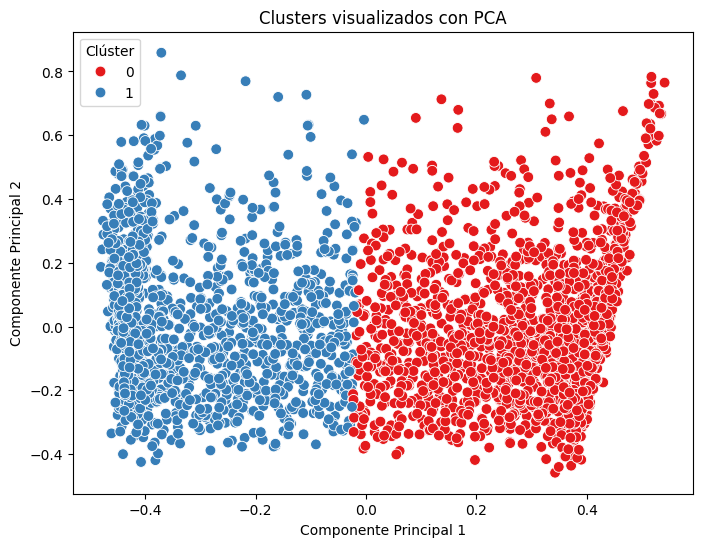

In [7]:
from sklearn.decomposition import PCA
import seaborn as sns

# Reducir a 2 componentes principales
pca = PCA(n_components=2)
datos_pca = pca.fit_transform(datos_escalados.drop(columns="etiquetas"))

# Crear un DataFrame para graficar
df_pca = pd.DataFrame(datos_pca, columns=["PC1", "PC2"])
df_pca["etiquetas"] = datos_escalados["etiquetas"]

# Graficar
plt.figure(figsize=(8, 6))
sns.scatterplot(data=df_pca, x="PC1", y="PC2", hue="etiquetas", palette="Set1", s=60)
plt.title("Clusters visualizados con PCA")
plt.xlabel("Componente Principal 1")
plt.ylabel("Componente Principal 2")
plt.legend(title="Clúster")
plt.show()


C:\Users\David\AppData\Local\Temp\ipykernel_25588\3230397053.py:21: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['cluster'] = cluster_labels


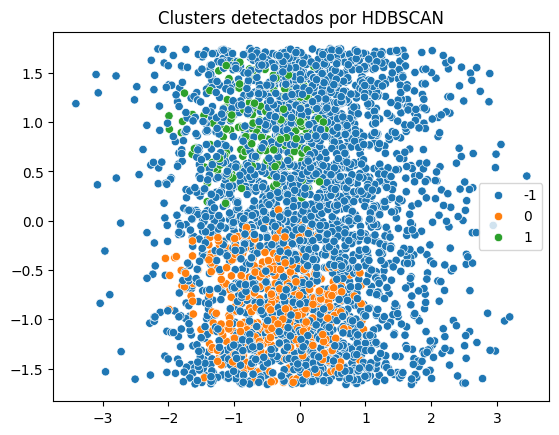

cluster
-1    2711
 0     489
 1     187
Name: count, dtype: int64


In [8]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
import hdbscan
import matplotlib.pyplot as plt
import seaborn as sns

# Cargar los datos (ejemplo con CSV)
# df = pd.read_csv('tus_datos.csv')

# Preprocesamiento
df=fdrec_modificado
X = df.select_dtypes(include=[np.number])  # selecciona solo columnas numéricas
X_scaled = StandardScaler().fit_transform(X)

# Crear modelo HDBSCAN
clusterer = hdbscan.HDBSCAN(min_cluster_size=10, metric='euclidean')
cluster_labels = clusterer.fit_predict(X_scaled)

# Agregar los labels al DataFrame
df['cluster'] = cluster_labels

# Visualización simple si tienes 2D o haces PCA
sns.scatterplot(x=X_scaled[:, 0], y=X_scaled[:, 1], hue=cluster_labels, palette='tab10')
plt.title('Clusters detectados por HDBSCAN')
plt.savefig("images/Clustering.png", dpi=300)
plt.show()

# Ver estadísticas
print(df['cluster'].value_counts())
